# Time Series Analysis (Declarative)
This case study demonstrates time series decomposition and stationarity testing using the pre-existing config `configs/02_time_series.yml`.

In [1]:
# Show the YAML configuration
with open('../configs/02_time_series.yml', 'r') as f:
    print(f.read())

02_Time_Series_Analysis_Declarative:
  data:
    source: 'examples/datasets/aapl_stock.csv'
    columns: ['Date', 'Close', 'Volume']
  steps:
    - name: 'trend_decomposition'
      type: 'decomposition'
      columns: ['Close']
      params:
        date_column: 'Date'
        model: 'multiplicative'
        period: 5
    - name: 'stationarity_check'
      type: 'stationarity'
      columns: ['Close']
      params:
        date_column: 'Date'
        alpha: 0.05
    - name: 'feature_engineering'
      type: 'ts_features'
      params:
        date_column: 'Date'
        lag_periods: [1, 5, 20]
        rolling_windows: [5, 20]
  output:
    path: 'examples/outputs/'
    format: ['html']



### Execute Pipeline

Column name changed: 'Date' -> 'date'
Column name changed: 'Open' -> 'open'
Column name changed: 'High' -> 'high'
Column name changed: 'Low' -> 'low'
Column name changed: 'Close' -> 'close'
Column name changed: 'Volume' -> 'volume'
Column name changed: 'Dividends' -> 'dividends'
Column name changed: 'Stock Splits' -> 'stock_splits'


╔══════════════════════════════════════════════════════════════╗
║  DSEngine  |  Experiment: 02_Time_Series_Analysis_Declarative ║
║  Config  : ../configs/02_time_series.yml                   ║
║  Started : 2026-03-24 20:31:39                             ║
╚══════════════════════════════════════════════════════════════╝
► Loading data...
  Source  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\datasets\aapl_stock.csv
  Shape   : 501 rows x 3 columns
  Columns : date, close, volume
► Pre-flight inspection...
  ✔  No fatal issues.
► Running steps (3 total):
  [1/3] trend_decomposition (decomposition ) ... done  (0.18s)
  [2/3] stationarity_check (stationarity  ) ... done  (0.02s)
  [3/3] feature_engineering (ts_features   ) ... done  (0.01s)
► Saving outputs...


D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\ds_engine\time_series\stationarity.py:58: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(s, regression='c', nlags='auto')


  Plots : 1 figure(s) → D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\02_Time_Series_Analysis_Declarative\20260324_203139\plots/
  JSON  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\02_Time_Series_Analysis_Declarative\20260324_203139\report.json
  HTML  : D:\OneDrive - STEPLESMOSENSESARL\PlesmoSense-CENTAN\Code\ACHRAF_Private\DS_Engine\examples\outputs\02_Time_Series_Analysis_Declarative\20260324_203139\report.html


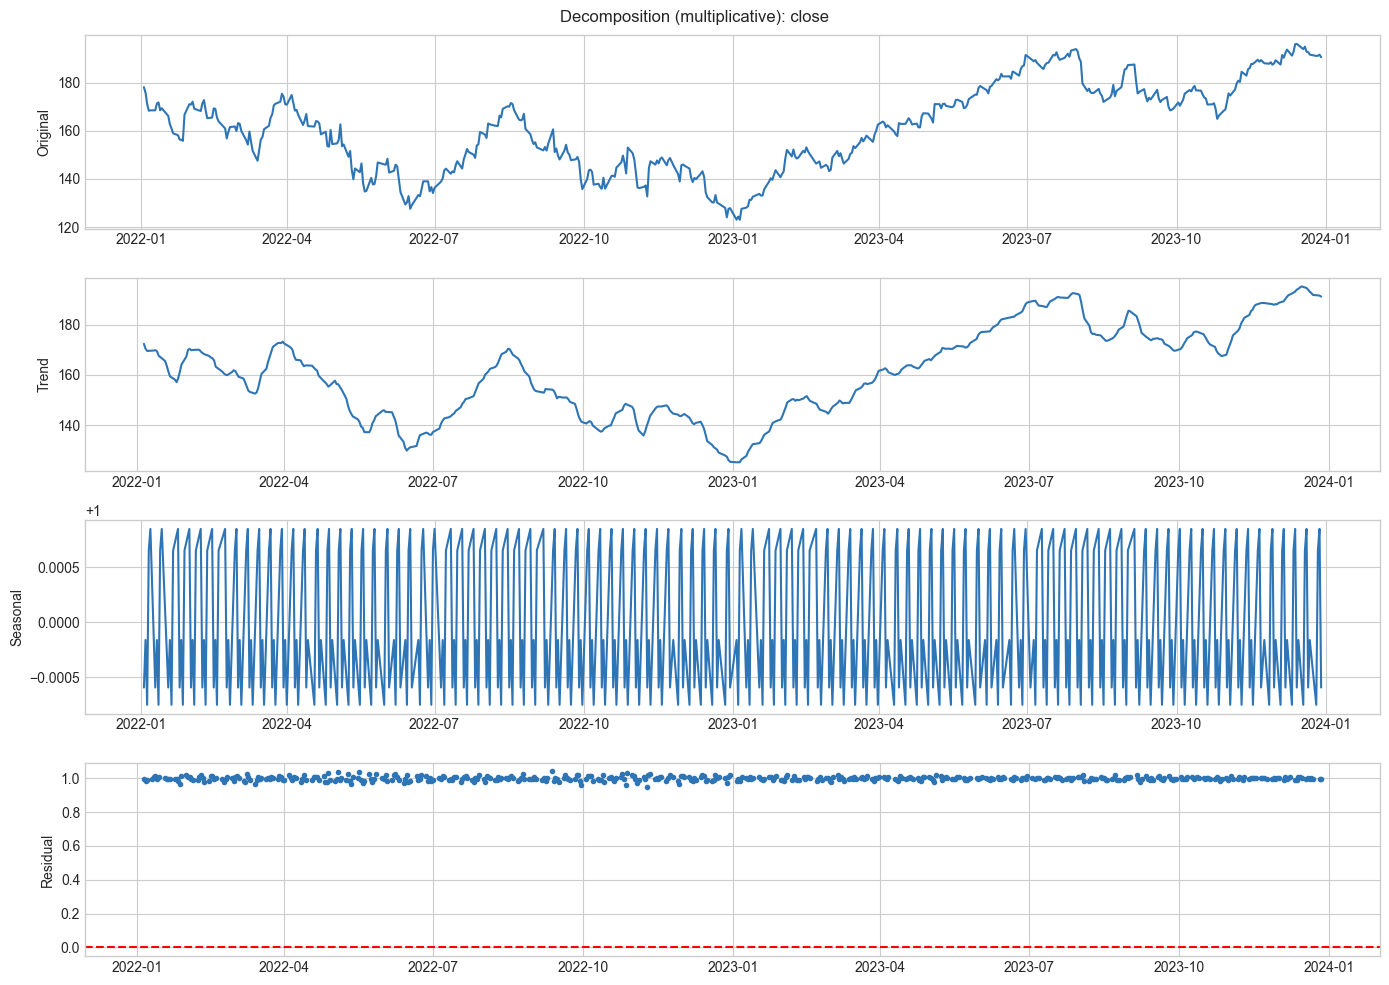

╔══════════════════════════════════════════════════════════════╗
║  ✔  Run complete                                             ║
║  Steps  : 3 completed, 0 failed                             ║
║  Time   : 2.21s total                                        ║
║  Output : outputs\02_Time_Series_Analysis_Declarative\20260324_203139 ║
╚══════════════════════════════════════════════════════════════╝


0

In [2]:
import sys, os, glob
from IPython.display import HTML, display
sys.path.insert(0, os.path.abspath('..'))
from ds_engine.utils import pipeline_runner

pipeline_runner.run('../configs/02_time_series.yml', '02_Time_Series_Analysis_Declarative')

### View Report

close,"{ ""residual_std"": 0.011865691645448897, ""seasonal_strength"": 0.002966183464307437, ""trend_strength"": 0.9999995400866174 }"
close,"{ ""adf_p_value"": 0.5273891076999025, ""adf_statistic"": -1.5123585815811966, ""interpretation"": ""Non-stationary or Mixed evidence"", ""is_stationary"": false, ""kpss_p_value"": 0.01, ""kpss_statistic"": 1.715559463869624 }"
new_columns_added,"[ ""year"", ""month"", ""day"", ""weekday"", ""quarter"", ""close_lag_1"", ""close_lag_5"", ""close_lag_20"", ""close_rolling_mean_5"", ""close_rolling_mean_20"", ""volume_lag_1"", ""volume_lag_5"", ""volume_lag_20"", ""volume_rolling_mean_5"", ""volume_rolling_mean_20"" ]"
original_shape,"[ 501, 3 ]"
new_shape,"[ 501, 18 ]"

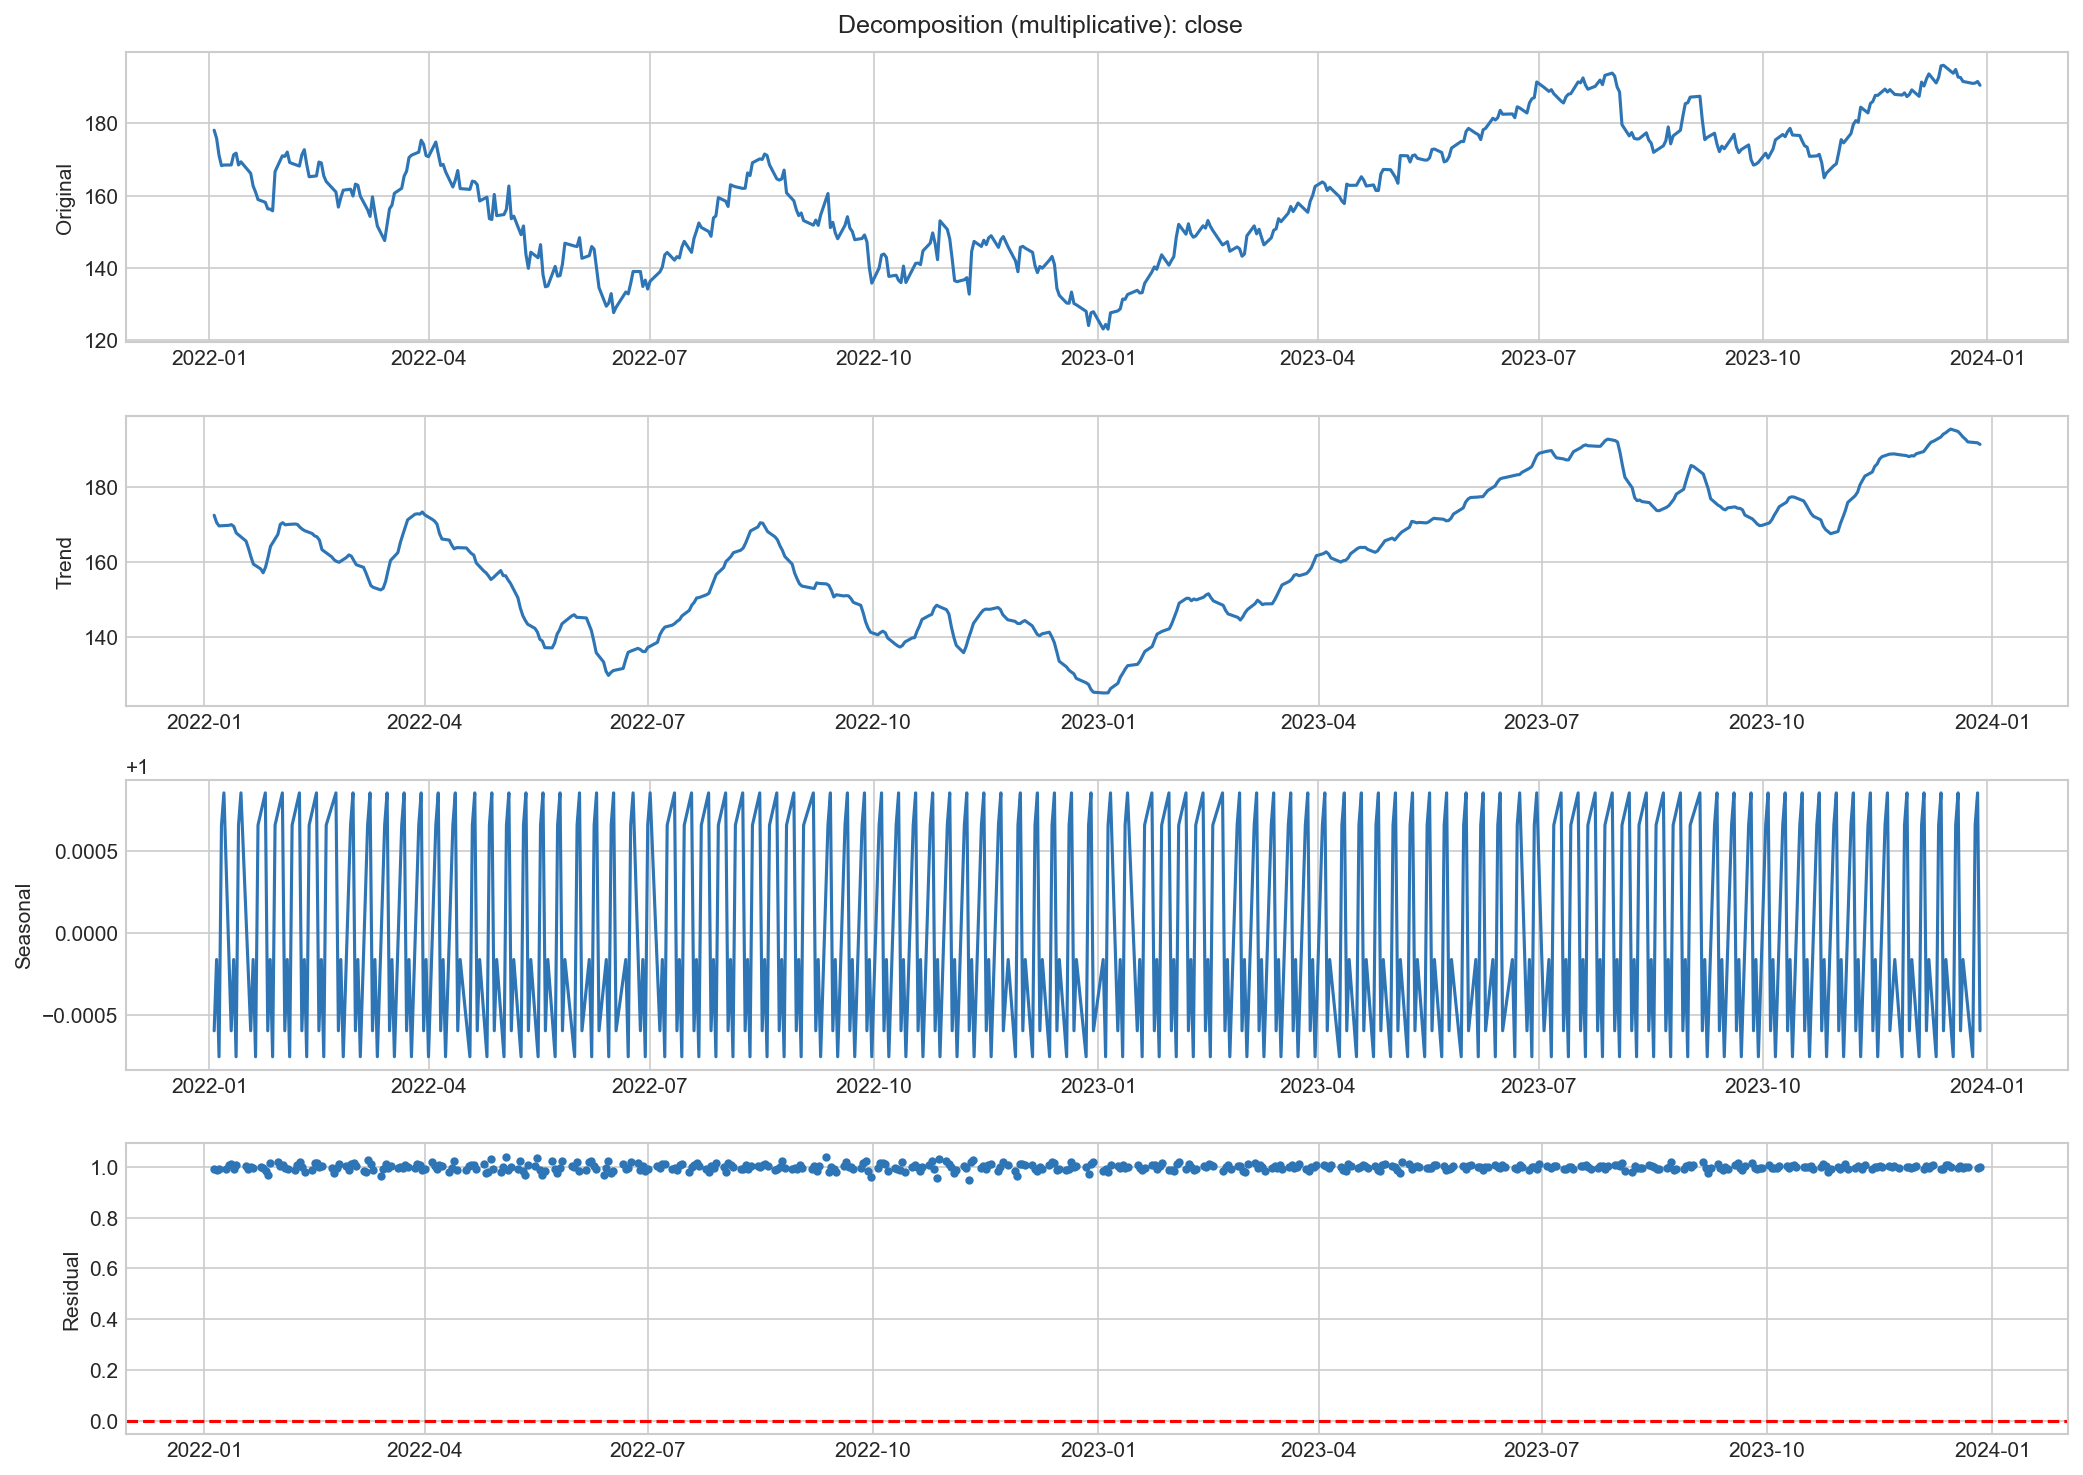

In [3]:
output_dirs = sorted(glob.glob('./outputs/02_Time_Series_Analysis_Declarative/*'))
if output_dirs:
    latest_report = os.path.join(output_dirs[-1], 'report.html')
    if os.path.exists(latest_report):
        display(HTML(latest_report))
